# Identification of key regulons associated with gene downregulation in mutants

**Purpose**

To identify key regulons whose predicted target genes are among genes downregulated in mutant conditions.

**Input**

* The output of the pySCENIC GRN inference step, containing transcription factors and their predicted target genes.

* An AnnData object comprising posterior midgut single-cell expression profiles.

* Lists of downregulated genes in LanB2 and tinman mutants relative to wild-type.

**Output**

A bipartite regulatory network highlighting the top transcription factors and their corresponding downregulated target genes in mutant conditions.



In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
#import seaborn as sns
sc.settings.set_figure_params(dpi=80, frameon=False)
sc.set_figure_params(dpi=80)
sc.set_figure_params(figsize=(4, 4))
plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (4, 4)

In [ ]:
import ast

from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

from itertools import chain
from collections import defaultdict

from upsetplot import from_indicators, UpSet


from matplotlib_venn import venn3

import networkx as nx


In [ ]:
adata=sc.read('../data/processed/PMG_6to9_allgenes_cycle.h5ad')
adata

In [ ]:
tf_target = pd.read_csv('../data/processed/regulon_TFnTargets_WT_PMG.csv', index_col=1)
tf_target['TF'] = tf_target.index

In [ ]:
tf_target

In [ ]:
# converting the string into a structured data
tf_target['Targets'] = tf_target['Targets'].apply(ast.literal_eval)

In [ ]:
tf_target

In [ ]:
adata = adata.raw.to_adata()
adata

In [ ]:
adata.layers['raw_counts'] = adata.X.copy()

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.X

In [ ]:
sc.tl.score_genes(adata, gene_list=tf_target['Targets'][0], score_name = 'BEAF_32')

In [ ]:
for i, tf in enumerate(tf_target.index, start=1):
    sc.tl.score_genes(adata, tf_target['Targets'][tf], score_name = f'{tf}_R{i}')


In [ ]:
adata

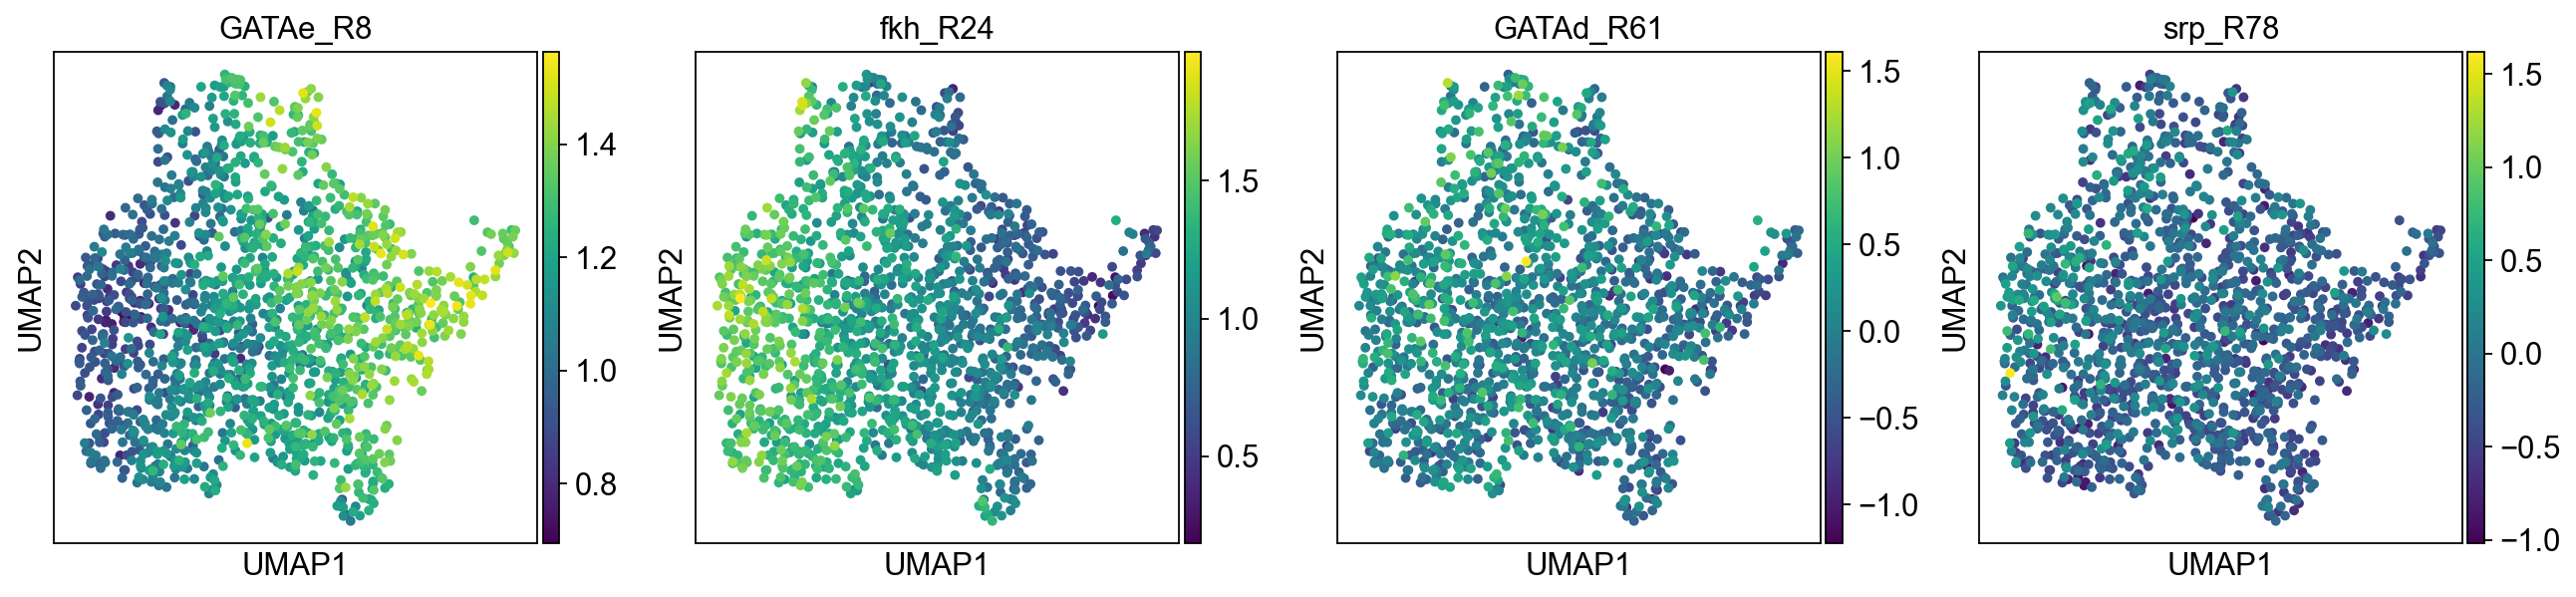

In [14]:
sc.pl.umap(adata, color=['GATAe_R8', 'fkh_R24', 'GATAd_R61', 'srp_R78'])

In [15]:
adata_sub.obs['time_interval'] = adata_sub.obs['time_interval'].astype('category')

NameError: name 'adata_sub' is not defined

In [ ]:
adata_sub.obs.groupby(['batch', 'time_interval']).size()

In [ ]:
min(adata_sub.obs.groupby(['batch', 'time_interval']).size())

In [ ]:
NUM_OF_CELL_PER_DONOR = 10

import random
def aggregate_and_filter(
    adata,
    cell_identity,
    donor_key="batch",
    condition_key="dataset_time",
    cell_identity_key="time_interval",
    obs_to_keep=[],  # which additional metadata to keep, e.g. gender, age, etc.
    replicates_per_patient=1,
):
    # subset adata to the given cell identity
    adata_cell_pop = adata[adata.obs[cell_identity_key] == cell_identity].copy()
    # check which donors to keep according to the number of cells specified with NUM_OF_CELL_PER_DONOR
    size_by_donor = adata_cell_pop.obs.groupby([donor_key]).size()
    donors_to_drop = [
        donor
        for donor in size_by_donor.index
        if size_by_donor[donor] <= NUM_OF_CELL_PER_DONOR
    ]
    if len(donors_to_drop) > 0:
        print("Dropping the following samples:")
        print(donors_to_drop)
    df = pd.DataFrame(columns=[*adata_cell_pop.var_names, *obs_to_keep])

    adata_cell_pop.obs[donor_key] = adata_cell_pop.obs[donor_key].astype("category")
    for i, donor in enumerate(donors := adata_cell_pop.obs[donor_key].cat.categories):
        print(f"\tProcessing donor {i+1} out of {len(donors)}...", end="\r")
        if donor not in donors_to_drop:
            adata_donor = adata_cell_pop[adata_cell_pop.obs[donor_key] == donor]
            # create replicates for each donor
            indices = list(adata_donor.obs_names)
            random.shuffle(indices)
            indices = np.array_split(np.array(indices), replicates_per_patient)
            for i, rep_idx in enumerate(indices):
                adata_replicate = adata_donor[rep_idx]
                # specify how to aggregate: sum gene expression for each gene for each donor and also keep the condition information
                agg_dict = {gene: "sum" for gene in adata_replicate.var_names}
                for obs in obs_to_keep:
                    agg_dict[obs] = "first"
                # create a df with all genes, donor and condition info
                df_donor = pd.DataFrame(adata_replicate.X)
                df_donor.index = adata_replicate.obs_names
                df_donor.columns = adata_replicate.var_names
                df_donor = df_donor.join(adata_replicate.obs[obs_to_keep])
                # aggregate
                df_donor = df_donor.groupby(donor_key).agg(agg_dict)
                df_donor[donor_key] = donor
                df.loc[f"donor_{donor}_{i}"] = df_donor.loc[donor]
    print("\n")
    # create AnnData object from the df
    adata_cell_pop = sc.AnnData(
        df[adata_cell_pop.var_names], obs=df.drop(columns=adata_cell_pop.var_names)
    )
    return adata_cell_pop

In [ ]:
%%R
fit_model <- function(adata_){
    # create an edgeR object with counts and grouping factor
    y <- DGEList(assay(adata_, "X"), group = colData(adata_)$dataset)
    # filter out genes with low counts
    print("Dimensions before subsetting:")
    print(dim(y))
    print("")
    keep <- filterByExpr(y)
    y <- y[keep, , keep.lib.sizes=FALSE]
    print("Dimensions after subsetting:")
    print(dim(y))
    print("")
    # normalize
    y <- calcNormFactors(y)
    # create a vector that is a concatenation of condition and cell type that we will later use with contrasts
    group <- colData(adata_)$dataset_time
    time <- colData(adata_)$time_interval
    library <- colData(adata_)$library
    # create a design matrix: here we have two very different library sizes so also consider that in the design matrix
    design <- model.matrix(~ group + library + time)
    # estimate dispersion
    y <- estimateDisp(y, design = design)
    # fit the model
    fit <- glmQLFit(y, design)
    return(list("fit"=fit, "design"=design, "y"=y))
}

In [ ]:
obs_to_keep = ["dataset", "time_interval", "replicate", "batch"]

In [ ]:
adata_sub.obs["time_interval"].dtype

In [ ]:
# process first cell type separately...
cell_type = adata_sub.obs["time_interval"].cat.categories[0]
print(
    f'Processing {cell_type} (1 out of {len(adata_sub.obs["time_interval"].cat.categories)})...'
)
adata_pb = aggregate_and_filter(adata_sub, cell_type, obs_to_keep=obs_to_keep)
for i, cell_type in enumerate(adata_sub.obs["time_interval"].cat.categories[1:]):
    print(
        f'Processing {cell_type} ({i+2} out of {len(adata_sub.obs["time_interval"].cat.categories)})...'
    )
    adata_cell_type = aggregate_and_filter(adata_sub, cell_type, obs_to_keep=obs_to_keep)
    adata_pb = adata_pb.concatenate(adata_cell_type)

In [ ]:
adata_pb.obs['library'] = adata_pb.obs['batch'].replace({'LanB_01':'library1', 'LanB_02':'library2', 'tin_01':'library1', 'tin_02':'library2', 'WT_03':'library1', 'WT_04':'library1'})

In [ ]:
adata_pb.X = adata_pb.layers['counts'].copy()

In [ ]:
adata_pb.obs_names = [
    name.split("_")[2] + "_" + name.split("_")[3] for name in adata_pb.obs_names
]

In [ ]:
del adata_pb.uns

In [ ]:
adata_pb

In [ ]:
adata_pb.obs['batch'] = adata_pb.obs['batch'].astype('category')

In [ ]:
# Extract expression matrix (genes x cells)
expression_df = pd.DataFrame(
    adata_pb.X.toarray() if hasattr(adata_pb.X, "toarray") else adata_pb.X,
    index=adata_pb.obs_names,  # Gene names as rows
    columns=adata_pb.var_names,  # Cell barcodes as columns
)

# Extract cell metadata
cell_metadata = adata_pb.obs.copy()


In [ ]:
expression_df

In [ ]:
cell_metadata

In [ ]:
%R -i expression_df -i cell_metadata

In [ ]:
%%R
expr_matrix <- as.matrix(expression_df)  # Ensure it's a matrix
col_metadata <- cell_metadata  # Metadata
adata_r <- SummarizedExperiment(
  assays = list(X = t(expr_matrix)),
  colData = col_metadata
)
adata_r

In [ ]:
%%R
assay(adata_r, "X")[1:5, 1:5]  # View the first few rows and columns of the assay
str(assay(adata_r, "X"))       # Check the structure of the assay

In [ ]:
%%R
assay(adata_r, "X") <- apply(assay(adata_r, "X"), c(1, 2), as.numeric)

In [ ]:
%%R
adata_r$dataset <- relevel(adata_r$dataset, ref="WT")

In [ ]:
%%R
levels(adata_r$dataset)

In [ ]:
%%R 
outs <-fit_model(adata_r)

In [ ]:
%%R
outs

In [ ]:
targets = []

for targets_list in tf_target['Targets']:
    targets.extend(targets_list)

targets = list(set(targets))
targets

In [ ]:
len(targets)

Importing the result of differentially expression analysis between mutants and wt (downregulated genes) and find those that are shared with the list of target genes.

In [ ]:
down_genes_tin = pd.read_csv('../data/report/DEG_tinVSwt_down_edgeR.csv', names= ['Gene', 'logFC', 'logCPM', 'F', 'pValue', 'FDR'])
down_genes_tin

In [ ]:
from collections import defaultdict


Creating a dictionary with keys as downregulated genes and elements as TFs appeared to be in the same regulon.

In [ ]:
gene_to_tfs = defaultdict(list)
gene_of_interest = down_genes_tin['Gene']

for tf, targets in zip(tf_target['TF'], tf_target['Targets']):
    for gene in gene_of_interest:
        if gene in targets:
            gene_to_tfs[gene].append(tf)

gene_to_tfs = dict(gene_to_tfs)

In [ ]:
gene_to_tfs

Counting the number of target genes for each TF that appeared as downregulated gene in mutant

In [ ]:
down_genes_set = set(down_genes_tin['Gene'])
tf_target_tin = pd.DataFrame(tf_target['TF'])

# Create a new column that stores the number of downregulated genes per TF
tf_target_tin['Num_down_targets'] = tf_target['Targets'].apply(
    lambda targets: len(set(targets) & down_genes_set)
)

# Optional: sort by number of downregulated targets
tf_target_tin = tf_target_tin.sort_values(by='Num_down_targets', ascending=False)

# View result
print(tf_target_tin[['TF', 'Num_down_targets']])

In [ ]:
down_genes_set = set(down_genes_tin['Gene'])

# Create a new DataFrame from tf_target
tf_target_tin = pd.DataFrame(tf_target[['TF', 'Targets']])

# Add column for number of overlapping downregulated targets
tf_target_tin['Num_down_targets'] = tf_target_tin['Targets'].apply(
    lambda targets: len(set(targets) & down_genes_set)
)

# Add column with the actual overlapping genes
tf_target_tin['Downregulated_targets'] = tf_target_tin['Targets'].apply(
    lambda targets: list(set(targets) & down_genes_set)
)

# Optional: sort by number of matches
tf_target_tin = tf_target_tin.sort_values(by='Num_down_targets', ascending=False)

# View result
print(tf_target_tin[['TF', 'Num_down_targets', 'Downregulated_targets']])

In [ ]:
tf_target_tin[0:10]

In [ ]:
down_genes_lan = pd.read_csv('../data/report/DEG_lanVSwt_down_edger.csv', names= ['Gene', 'logFC', 'logCPM', 'F', 'pValue', 'FDR'])
down_genes_lan

In [ ]:
down_genes_set = set(down_genes_lan['Gene'])
tf_target_lan = pd.DataFrame(tf_target['TF'])

# Create a new column that stores the number of downregulated genes per TF
tf_target_lan['Num_down_targets'] = tf_target['Targets'].apply(
    lambda targets: len(set(targets) & down_genes_set)
)

# Optional: sort by number of downregulated targets
tf_target_lan = tf_target_lan.sort_values(by='Num_down_targets', ascending=False)

# View result
print(tf_target_lan[['TF', 'Num_down_targets']])

In [ ]:
down_genes_set = set(down_genes_lan['Gene'])

# Create a new DataFrame from tf_target
tf_target_lan = pd.DataFrame(tf_target[['TF', 'Targets']])

# Add column for number of overlapping downregulated targets
tf_target_lan['Num_down_targets'] = tf_target_lan['Targets'].apply(
    lambda targets: len(set(targets) & down_genes_set)
)

# Add column with the actual overlapping genes
tf_target_lan['Downregulated_targets'] = tf_target_lan['Targets'].apply(
    lambda targets: list(set(targets) & down_genes_set)
)

# Optional: sort by number of matches
tf_target_lan = tf_target_lan.sort_values(by='Num_down_targets', ascending=False)

# View result
print(tf_target_lan[['TF', 'Num_down_targets', 'Downregulated_targets']])

In [ ]:
down_genes = list (set(down_genes_tin['Gene']) & set(down_genes_lan['Gene']))
down_genes

In [ ]:
down_genes_set = set(down_genes)

# Create a new DataFrame from tf_target
tf_target_all = pd.DataFrame(tf_target[['TF', 'Targets']])

# Add column for number of overlapping downregulated targets
tf_target_all['Num_down_targets'] = tf_target_all['Targets'].apply(
    lambda targets: len(set(targets) & down_genes_set)
)

# Add column with the actual overlapping genes
tf_target_all['Downregulated_targets'] = tf_target_all['Targets'].apply(
    lambda targets: list(set(targets) & down_genes_set)
)

# Optional: sort by number of matches
tf_target_all = tf_target_all.sort_values(by='Num_down_targets', ascending=False)

print(tf_target_all[['TF', 'Num_down_targets', 'Downregulated_targets']])

In [ ]:
tf_target_all[0:10]

In [ ]:
tf_target_tin = tf_target_tin[0:10]
tf_target_tin

/Users/royaab/miniconda3/envs/palantir_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/royaab/miniconda3/envs/palantir_env/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on whi

<Figure size 960x1120 with 0 Axes>

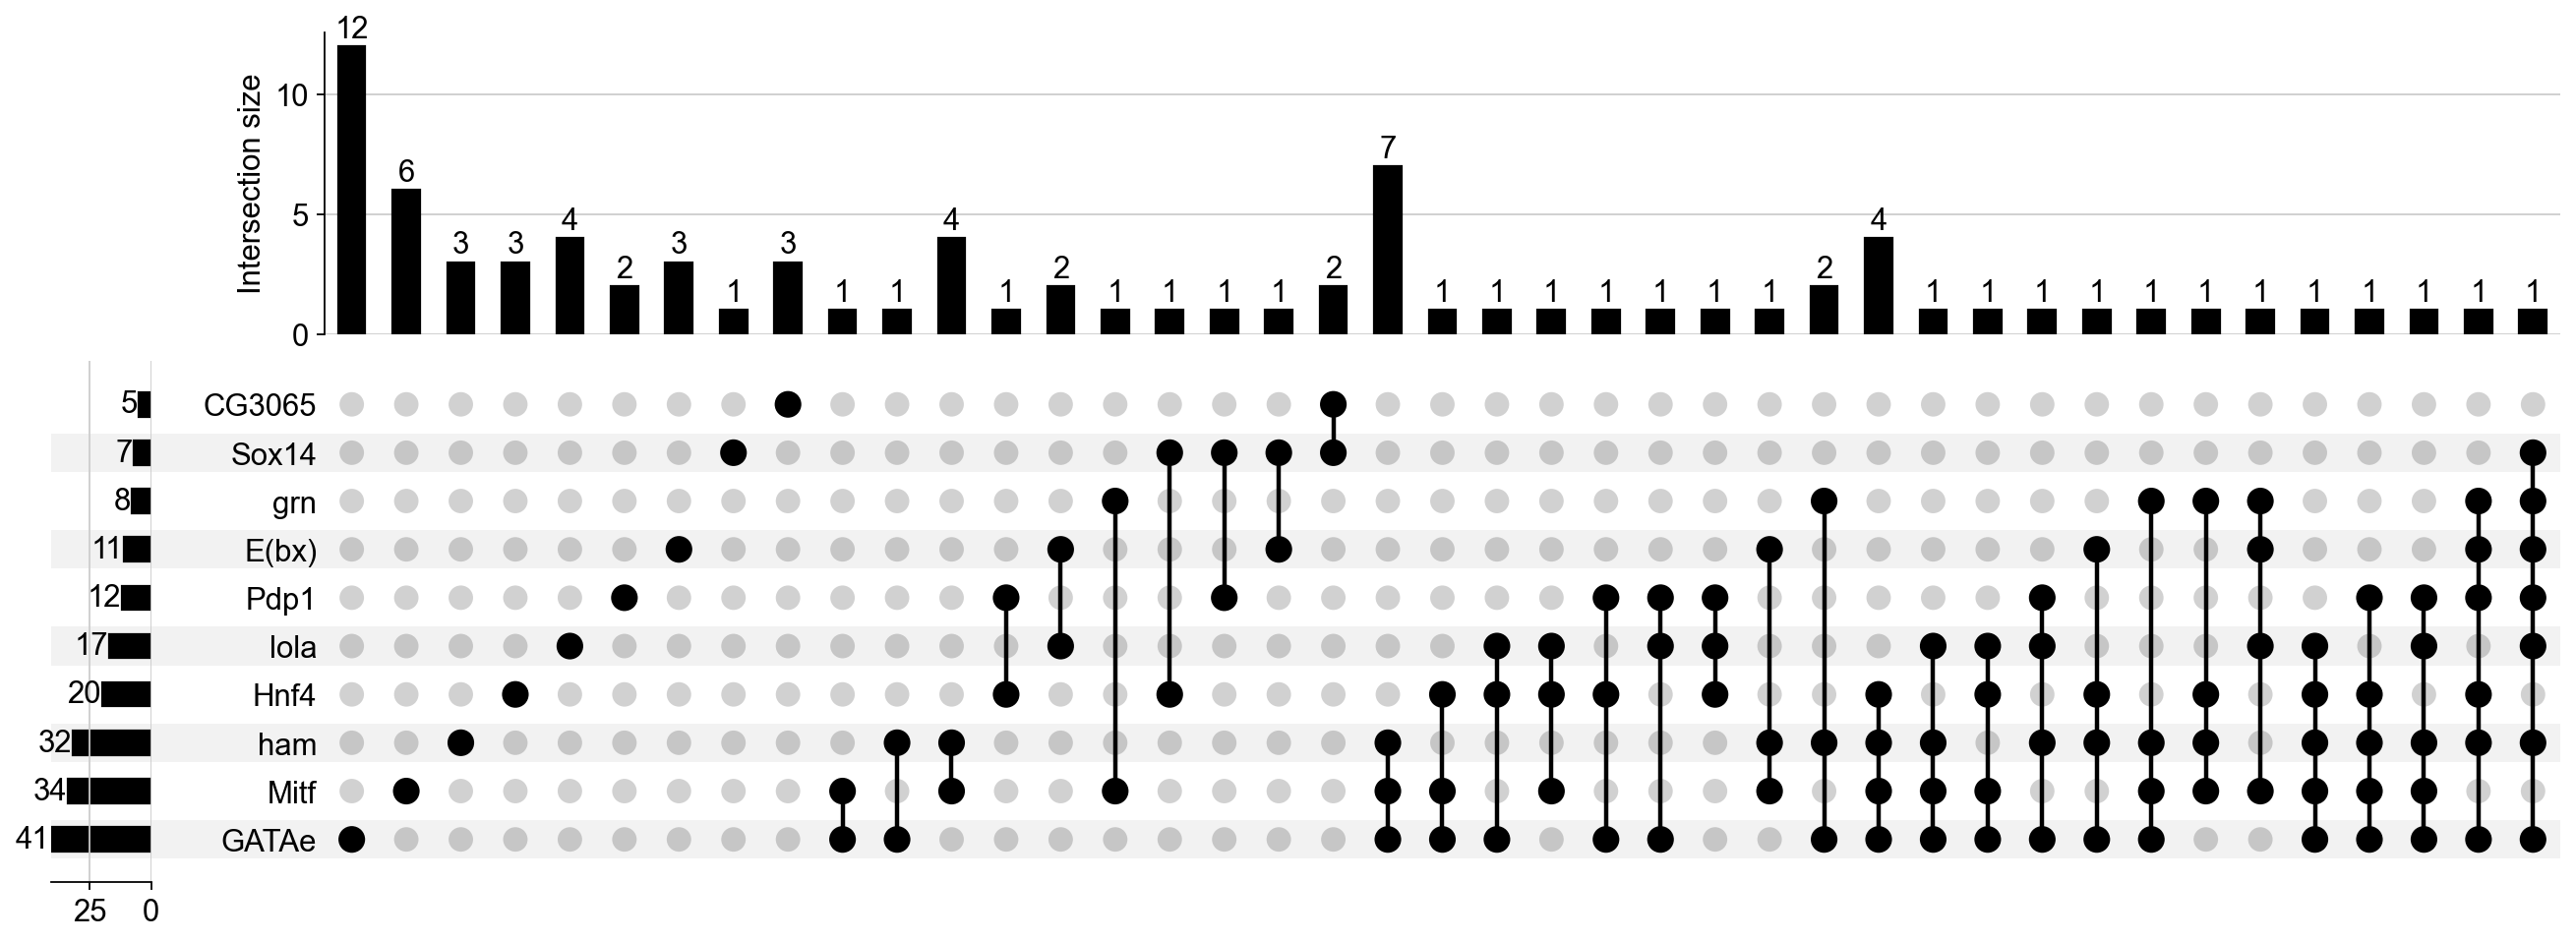

In [33]:
plt.figure(figsize=(12, 14))
# Build binary matrix: rows = genes, columns = TFs
gene_to_tfs = defaultdict(set)
for _, row in tf_target_tin.iterrows():
    tf = row['TF']
    for gene in row['Downregulated_targets']:
        gene_to_tfs[gene].add(tf)

# Get all TFs
all_tfs = tf_target_tin['TF'].tolist()
# Build gene-TF matrix
gene_matrix = pd.DataFrame([
    {tf: tf in gene_to_tfs[gene] for tf in all_tfs}
    for gene in gene_to_tfs
], index=gene_to_tfs.keys())
# This is the correct input for UpSet:
upset_data = from_indicators(gene_matrix)

UpSet(upset_data, show_counts=True, subset_size='count').plot()
plt.show()

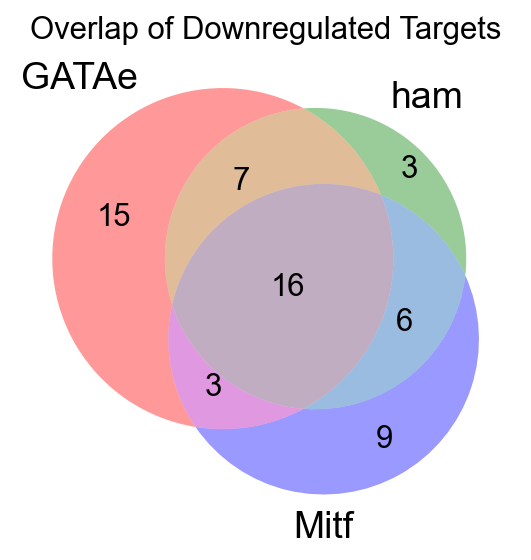

In [35]:
tf_sub = tf_target_tin.loc[tf_target_tin['TF'].isin(['GATAe', 'ham', 'Mitf'])].set_index('TF')
sets = {tf: set(targets) for tf, targets in tf_sub['Downregulated_targets'].items()}

venn3(subsets=(sets['GATAe'], sets['ham'], sets['Mitf']),
      set_labels=('GATAe', 'ham', 'Mitf'))
plt.title("Overlap of Downregulated Targets")
plt.show()

In [ ]:
tf_target_lan = tf_target_lan[0:10]
tf_target_lan

/Users/royaab/miniconda3/envs/palantir_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/royaab/miniconda3/envs/palantir_env/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on whi

<Figure size 960x1120 with 0 Axes>

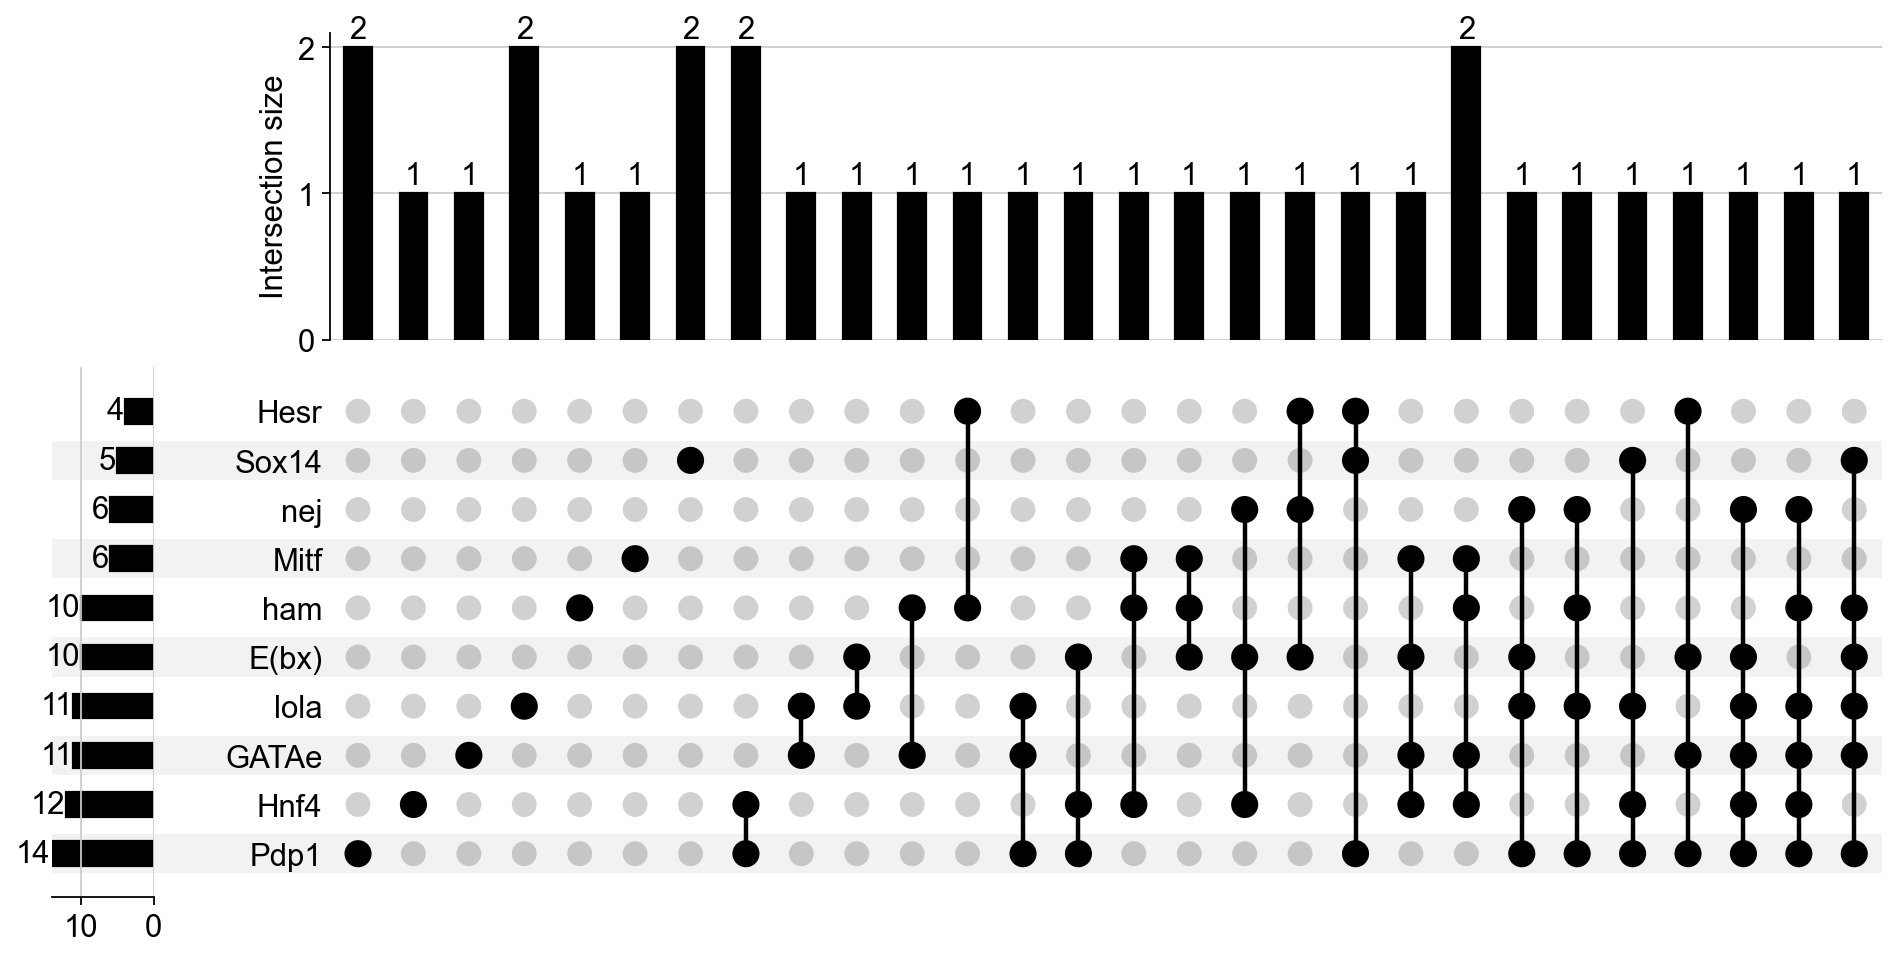

In [37]:
plt.figure(figsize=(12, 14))
# Build binary matrix: rows = genes, columns = TFs
gene_to_tfs = defaultdict(set)
for _, row in tf_target_lan.iterrows():
    tf = row['TF']
    for gene in row['Downregulated_targets']:
        gene_to_tfs[gene].add(tf)

# Get all TFs
all_tfs = tf_target_lan['TF'].tolist()
# Build gene-TF matrix
gene_matrix = pd.DataFrame([
    {tf: tf in gene_to_tfs[gene] for tf in all_tfs}
    for gene in gene_to_tfs
], index=gene_to_tfs.keys())
# This is the correct input for UpSet:
upset_data = from_indicators(gene_matrix)

UpSet(upset_data, show_counts=True, subset_size='count').plot()
plt.show()

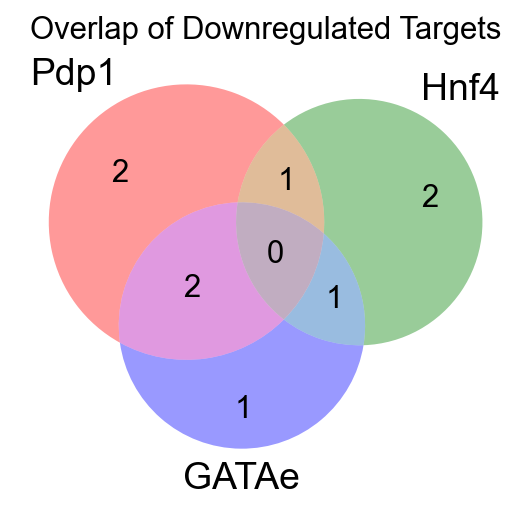

In [38]:
tf_sub = tf_target_all.loc[tf_target_all['TF'].isin(['Pdp1', 'Hnf4', 'GATAe'])].set_index('TF')
sets = {tf: set(targets) for tf, targets in tf_sub['Downregulated_targets'].items()}

venn3(subsets=(sets['Pdp1'], sets['Hnf4'], sets['GATAe']),
      set_labels=('Pdp1', 'Hnf4', 'GATAe'))
plt.title("Overlap of Downregulated Targets")
plt.show()

In [ ]:
tf_target_all01 = tf_target_all.copy()

In [ ]:
tf_target_all = tf_target_all[0:5]
tf_target_all

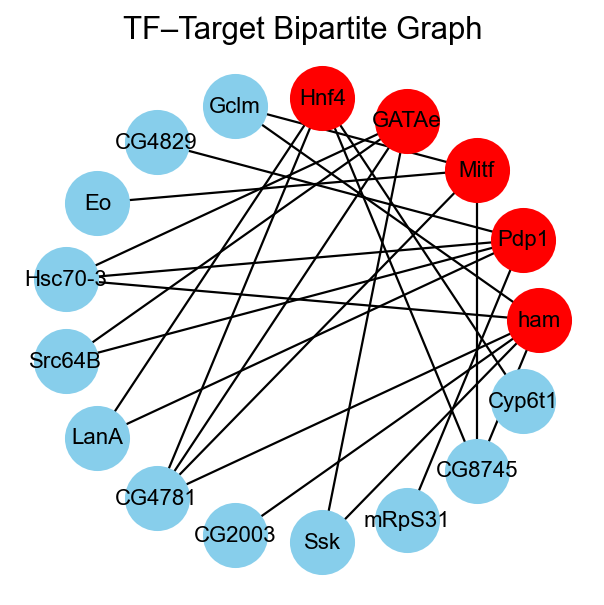

In [42]:
# Create bipartite graph
B = nx.Graph()

# Extract TFs from the index
TFs = tf_target_all.index.tolist()

# Extract all unique genes
genes = set(gene for targets in tf_target_all['Downregulated_targets'] for gene in targets)

# Add TF and gene nodes
B.add_nodes_from(TFs, bipartite='TF')
B.add_nodes_from(genes, bipartite='gene')

# Add edges between TFs and their targets
for tf, targets in tf_target_all['Downregulated_targets'].items():
    for gene in targets:
        B.add_edge(tf, gene)

# Define bipartite layout: TFs on the left (x=0), genes on the right (x=1)
pos = {}
pos.update((tf, (0, i)) for i, tf in enumerate(TFs))  # TFs at x=0
pos.update((gene, (1, i)) for i, gene in enumerate(genes))  # genes at x=1

# Draw nodes
pos = nx.circular_layout(B)
nx.draw_networkx_nodes(B, pos, nodelist=TFs, node_color='red', node_size=800, label='TFs')
nx.draw_networkx_nodes(B, pos, nodelist=genes, node_color='skyblue', node_size=800, label='Genes')

# Draw edges
nx.draw_networkx_edges(B, pos)

# Draw labels
nx.draw_networkx_labels(B, pos, font_size=10)

# Final touches
plt.title("TF–Target Bipartite Graph")
plt.axis('off')
plt.tight_layout()
plt.show()